<img src="https://elementos.entornos.net/clientes/ISPC/ispc.png" width="350" height="200">

#**TECNICATURA SUPERIOR EN CIENCIAS DE DATOS E INTELIGENCIA ARTIFICIAL**

##**"PROCESAMIENTO DE IMÁGENES"**

TERCER AÑO - COHORTE 2024


---

## **DESARROLLO Y AVANCE TÉCNICO**

---

## Docente:
Carlos CHARLETTI

## Estudiantes:


*  Allende Olmedo Nicolás
*  Direni Carlos
*  García Carlos
*  Guaraz Emanuel
*  Moreno Raúl
*  Testa Andrea Paola
*  Villalba Valeria Nieves


Mayo de 2026

# **🌩️ CCSN Dataset — Normalización para MobileNetV2**
**Dataset:** Cirrus Cumulus Stratus Nimbus (Zhang et al., 2018)  
**Proyecto:** Predicción climática · Río Tercero, Córdoba  
**Clases:** 11 tipos de nube según la OMM  
**Imágenes:** 2543 JPEG · 256×256 px · color RGB

---
### Bloques del notebook
| Bloque | Contenido |
|--------|-----------|
| 1 | Instalación de dependencias |
| 2 | Descarga del dataset desde Kaggle |
| 3 | Inspección del dataset crudo |
| 4 | Normalización: `preprocess_input` MobileNetV2 |
| 5 | Verificación visual y estadística |
| 6 | Guardado del dataset normalizado |
| 7 | Prueba técnica de funcionamiento |
| 8 | Prueba técnica de funcionamiento con Random |

> ⚠️ **Antes de ejecutar:** Ir a `Entorno de ejecución → Cambiar tipo de entorno → GPU (T4)`

---
## **📦 BLOQUE 1 — Instalación de dependencias**

In [ ]:
# kaggle  → descarga del dataset
# todo lo demás ya viene en Colab (tensorflow, numpy, matplotlib, PIL)

!pip install -q kaggle

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
import os, zipfile, json
from collections import Counter
import kagglehub
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

print(f'✓ TensorFlow: {tf.__version__}')
print(f'✓ GPU disponible: {tf.config.list_physical_devices("GPU")}')
print('✓ Dependencias listas')

✓ TensorFlow: 2.20.0
✓ GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✓ Dependencias listas


---
## **🔑 BLOQUE 2 — Descarga del dataset desde Kaggle**



In [ ]:
path = kagglehub.dataset_download("mmichelli/cirrus-cumulus-stratus-nimbus-ccsn-database")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cirrus-cumulus-stratus-nimbus-ccsn-database' dataset.
Path to dataset files: /kaggle/input/cirrus-cumulus-stratus-nimbus-ccsn-database


---
## **🔍 BLOQUE 3 — Inspección del dataset crudo**
Antes de normalizar, miramos los valores reales de píxel tal como vienen del JPEG.

In [ ]:
 # Detectar la carpeta raíz correcta (puede variar según cómo venga el zip)
def find_dataset_root(base_dir: Path) -> Path:
    """Encuentra la carpeta que contiene las subcarpetas de clases CCSN."""
    ccsn_classes = {'Ac','As','Cb','Cc','Ci','Cs','Ct','Cu','Ns','Sc','St'}
    for d in [base_dir] + list(base_dir.iterdir()):
        if d.is_dir():
            children = {c.name for c in d.iterdir() if c.is_dir()}
            if children & ccsn_classes:   # intersección no vacía
                return d
    raise FileNotFoundError(f'No se encontró la estructura CCSN en {base_dir}')

DATA_ROOT = find_dataset_root(Path(path))
print(f'✓ Carpeta raíz del dataset: {DATA_ROOT}')

# Contar imágenes por clase
CLASS_NAMES = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f'\n📊 Clases encontradas: {CLASS_NAMES}')
print(f'   Total clases: {len(CLASS_NAMES)}')

print('\n📊 Distribución por clase:')
counts = {}
for cls in CLASS_NAMES:
    imgs = list((DATA_ROOT / cls).glob('*'))
    imgs = [f for f in imgs if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    counts[cls] = len(imgs)
    bar = '█' * (counts[cls] // 5)
    print(f'   {cls:3s}: {counts[cls]:4d}  {bar}')

print(f'\n   TOTAL: {sum(counts.values())} imágenes')


✓ Carpeta raíz del dataset: /kaggle/input/cirrus-cumulus-stratus-nimbus-ccsn-database/CCSN_v2

📊 Clases encontradas: ['Ac', 'As', 'Cb', 'Cc', 'Ci', 'Cs', 'Ct', 'Cu', 'Ns', 'Sc', 'St']
   Total clases: 11

📊 Distribución por clase:
   Ac :  221  ████████████████████████████████████████████
   As :  188  █████████████████████████████████████
   Cb :  242  ████████████████████████████████████████████████
   Cc :  268  █████████████████████████████████████████████████████
   Ci :  139  ███████████████████████████
   Cs :  287  █████████████████████████████████████████████████████████
   Ct :  200  ████████████████████████████████████████
   Cu :  182  ████████████████████████████████████
   Ns :  274  ██████████████████████████████████████████████████████
   Sc :  340  ████████████████████████████████████████████████████████████████████
   St :  202  ████████████████████████████████████████

   TOTAL: 2543 imágenes


## BLOQUE 3 B: Estadísticas de píxeles CRUDOS

In [ ]:
# Muestreamos 10 imágenes de cada clase para estimar la distribución
# de valores de píxel ANTES de normalizar. Rango esperado: [0, 255]

all_pixels_sample = []
sample_per_class  = 10

for cls in CLASS_NAMES:
    img_files = sorted((DATA_ROOT / cls).glob('*.jpg'))[:sample_per_class]
    for f in img_files:
        img = np.array(Image.open(f).convert('RGB'), dtype=np.float32)
        all_pixels_sample.append(img)

pixel_stack = np.concatenate([p.ravel() for p in all_pixels_sample])

print('📊 Estadísticas de píxeles CRUDOS (muestra, uint8 / float32):')
print(f'   Min:    {pixel_stack.min():.1f}')
print(f'   Max:    {pixel_stack.max():.1f}')
print(f'   Media:  {pixel_stack.mean():.2f}')
print(f'   Std:    {pixel_stack.std():.2f}')
print(f'   Rango esperado: [0, 255] ← correcto para imágenes JPEG sin normalizar')

# También chequeamos que todas son 256×256
sizes = set()
for cls in CLASS_NAMES:
    for f in (DATA_ROOT / cls).glob('*.jpg'):
        sizes.add(Image.open(f).size)
        break   # solo la primera de cada clase
print(f'\n   Tamaños encontrados: {sizes}')
if sizes == {(256, 256)}:
    print('   ✓ Todas las imágenes son 256×256 px')
else:
    print('   ⚠️  Hay imágenes con tamaños distintos — el pipeline de carga hará resize')

📊 Estadísticas de píxeles CRUDOS (muestra, uint8 / float32):
   Min:    0.0
   Max:    255.0
   Media:  129.08
   Std:    68.94
   Rango esperado: [0, 255] ← correcto para imágenes JPEG sin normalizar

   Tamaños encontrados: {(400, 400), (256, 256)}
   ⚠️  Hay imágenes con tamaños distintos — el pipeline de carga hará resize


## BLOQUE 3 C: Grilla visual de imágenes crudas (una por clase)

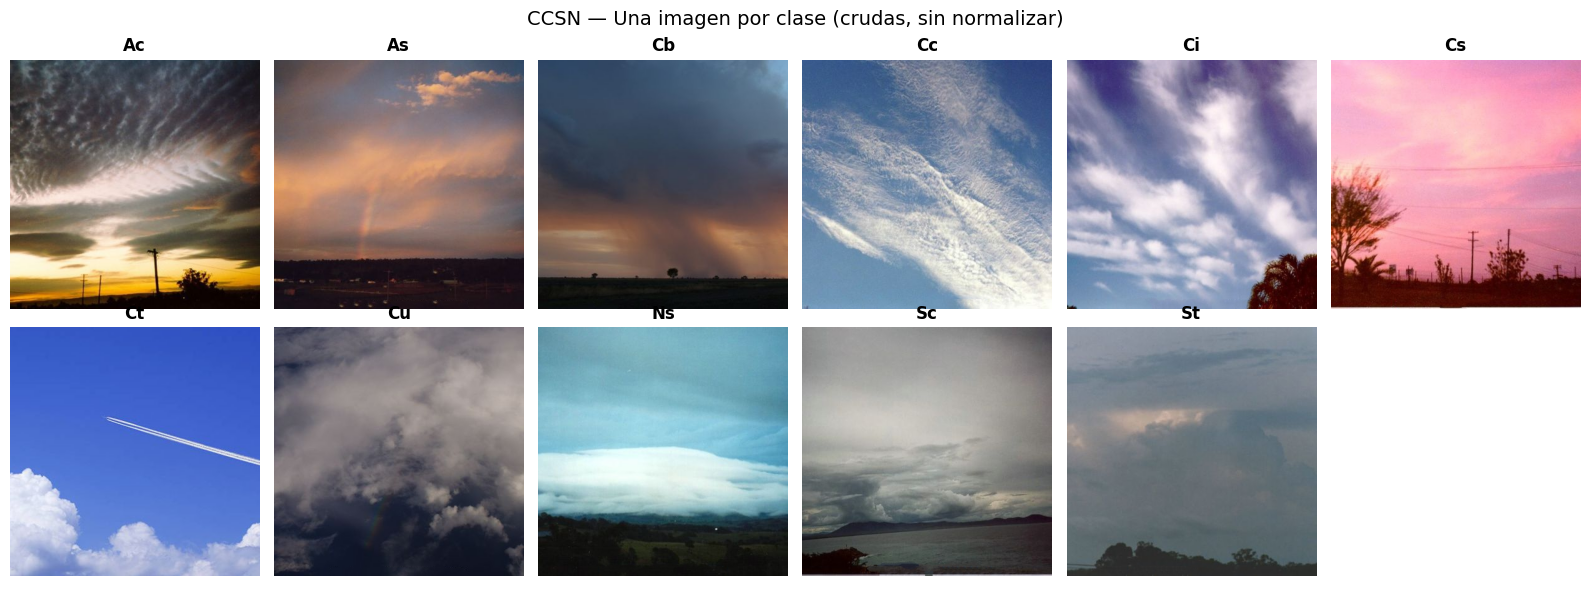

✓ Grilla guardada en /content/ccsn_raw_grid.png


In [ ]:
n_classes = len(CLASS_NAMES)
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
axes = axes.ravel()

for i, cls in enumerate(CLASS_NAMES):
    img_file = sorted((DATA_ROOT / cls).glob('*.jpg'))[0]
    img = Image.open(img_file).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=12, fontweight='bold')
    axes[i].axis('off')

# Ocultar el subplot sobrante (tenemos 11 clases en grilla 2x6=12)
axes[-1].axis('off')

plt.suptitle('CCSN — Una imagen por clase (crudas, sin normalizar)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/ccsn_raw_grid.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ Grilla guardada en /content/ccsn_raw_grid.png')

---
## **⚙️ BLOQUE 4 — Normalización**

### ¿Por qué `preprocess_input` y no `/255`?

MobileNetV2 fue pre-entrenado en ImageNet usando `preprocess_input` de Keras,  
que hace la siguiente transformación:

```
pixel_norm = (pixel_crudo / 127.5) - 1.0
```

Esto mapea `[0, 255]` → `[-1.0, 1.0]`.  
Si normalizamos con `/255` (→ `[0, 1]`), el modelo empieza con los pesos  
pre-entrenados desalineados con la distribución que esperan, lo que hace  
que el fine-tuning sea más lento y, en algunos casos, no converja bien.

| Normalización | Rango salida | Correcto para MobileNetV2 |
|---|---|---|
| `/ 255` | `[0, 1]` | ❌ |
| `/ 127.5 - 1` (`preprocess_input`) | `[-1, 1]` | ✅ |
| Estandarización z-score | media≈0, std≈1 | ❌ (no estándar para este modelo) |

##BLOQUE 4 A: Parámetros de normalización

In [ ]:
IMG_SIZE   = (50, 50)   # input requerido por MobileNetV2 (resize de 256→50)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE
SEED       = 42

# Clases en orden alfabético (como las asigna TF automáticamente)
# Ac=0 As=1 Cb=2 Cc=3 Ci=4 Cs=5 Ct=6 Cu=7 Ns=8 Sc=9 St=10
CLASS_NAMES_TF = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
print(f'Clases (orden TF): {CLASS_NAMES_TF}')
print(f'IMG_SIZE target:   {IMG_SIZE}  (resize de 256→50 para MobileNetV2)')
print(f'Normalización:     preprocess_input  →  rango [-1, 1]')

Clases (orden TF): ['Ac', 'As', 'Cb', 'Cc', 'Ci', 'Cs', 'Ct', 'Cu', 'Ns', 'Sc', 'St']
IMG_SIZE target:   (50, 50)  (resize de 256→50 para MobileNetV2)
Normalización:     preprocess_input  →  rango [-1, 1]


## BLOQUE 4 B: Función de normalización y Carga

In [ ]:
def normalize_mobilenetv2(image, label):
    """
    Normalización oficial para MobileNetV2 pre-entrenado en ImageNet.

    Pasos:
      1. Cast a float32  (viene como uint8 de la imagen JPEG)
      2. preprocess_input: (x / 127.5) - 1.0  →  rango [-1, 1]

    El resize (256→50) ya lo hace image_dataset_from_directory
    antes de llegar aquí.
    """
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label


def load_and_normalize(data_root: Path, validation_split: float = 0.2):
    """
    Carga el CCSN, hace resize 256→50 y aplica normalización [-1, 1].

    Returns:
        ds_train_norm  — dataset de training normalizado, sin batch
        ds_val_norm    — dataset de validación normalizado, sin batch
        class_names    — lista de nombres de clases en orden TF
    """
    common_args = dict(
        directory        = str(data_root),
        image_size       = IMG_SIZE,     # resize automático 256→50
        batch_size       = None,         # sin batch aquí, lo hacemos al final
        label_mode       = 'int',        # labels como enteros 0-10
        seed             = SEED,
        validation_split = validation_split,
    )

    ds_train_raw = tf.keras.utils.image_dataset_from_directory(
        subset  = 'training',
        shuffle = True,
        **common_args
    )
    ds_val_raw = tf.keras.utils.image_dataset_from_directory(
        subset  = 'validation',
        shuffle = False,   # val nunca se shufflea
        **common_args
    )

    class_names = ds_train_raw.class_names

    # Aplicar normalización como map()
    ds_train_norm = ds_train_raw.map(normalize_mobilenetv2, num_parallel_calls=AUTOTUNE)
    ds_val_norm   = ds_val_raw.map(normalize_mobilenetv2,   num_parallel_calls=AUTOTUNE)

    return ds_train_norm, ds_val_norm, class_names


print('✓ Funciones de normalización definidas')

✓ Funciones de normalización definidas


## BLOQUE 4 C: Ejecutar la normalización

In [ ]:
ds_train_norm, ds_val_norm, class_names = load_and_normalize(DATA_ROOT)

print(f'\n✓ Normalización aplicada')
print(f'   Clases (orden TF): {class_names}')

# Contar muestras
n_train = sum(1 for _ in ds_train_norm)
n_val   = sum(1 for _ in ds_val_norm)
print(f'   Training:   {n_train} imágenes')
print(f'   Validación: {n_val} imágenes')
print(f'   Split:      {n_train/(n_train+n_val)*100:.0f}% / {n_val/(n_train+n_val)*100:.0f}%')

Found 2543 files belonging to 11 classes.
Using 2035 files for training.
Found 2543 files belonging to 11 classes.
Using 508 files for validation.

✓ Normalización aplicada
   Clases (orden TF): ['Ac', 'As', 'Cb', 'Cc', 'Ci', 'Cs', 'Ct', 'Cu', 'Ns', 'Sc', 'St']
   Training:   2035 imágenes
   Validación: 508 imágenes
   Split:      80% / 20%


---
## **✅BLOQUE 5 — Verificación visual y estadística**
Confirmamos que la normalización funcionó correctamente antes de usar el dataset.

## BLOQUE 5 A: Verificación numérica

In [ ]:
# Tomar una muestra del training set para inspeccionar
sample_imgs, sample_labels = next(iter(ds_train_norm.batch(64)))

pixels = sample_imgs.numpy().ravel()

print('📊 Estadísticas de píxeles POST-normalización:')
print(f'   Min:    {pixels.min():.4f}   (esperado ≈ -1.0)')
print(f'   Max:    {pixels.max():.4f}   (esperado ≈  1.0)')
print(f'   Media:  {pixels.mean():.4f}  (esperado ≈ -0.1 a 0.1)')
print(f'   Std:    {pixels.std():.4f}')
print(f'   Shape:  {sample_imgs.shape} = (batch, alto, ancho, canales)')

# Assertions para detectar errores silenciosos
assert pixels.min() >= -1.05, f'ERROR: píxel mínimo {pixels.min()} fuera de rango'
assert pixels.max() <=  1.05, f'ERROR: píxel máximo {pixels.max()} fuera de rango'
assert sample_imgs.shape[1:] == (50, 50, 3), f'ERROR: shape incorrecto {sample_imgs.shape}'

print('\n✓ Todos los checks pasaron — normalización correcta')

📊 Estadísticas de píxeles POST-normalización:
   Min:    -1.0000   (esperado ≈ -1.0)
   Max:    1.0000   (esperado ≈  1.0)
   Media:  0.0583  (esperado ≈ -0.1 a 0.1)
   Std:    0.5116
   Shape:  (64, 50, 50, 3) = (batch, alto, ancho, canales)

✓ Todos los checks pasaron — normalización correcta


## BLOQUE 5 B: Visualización de Histograma "crudo" vs. "normalizado"

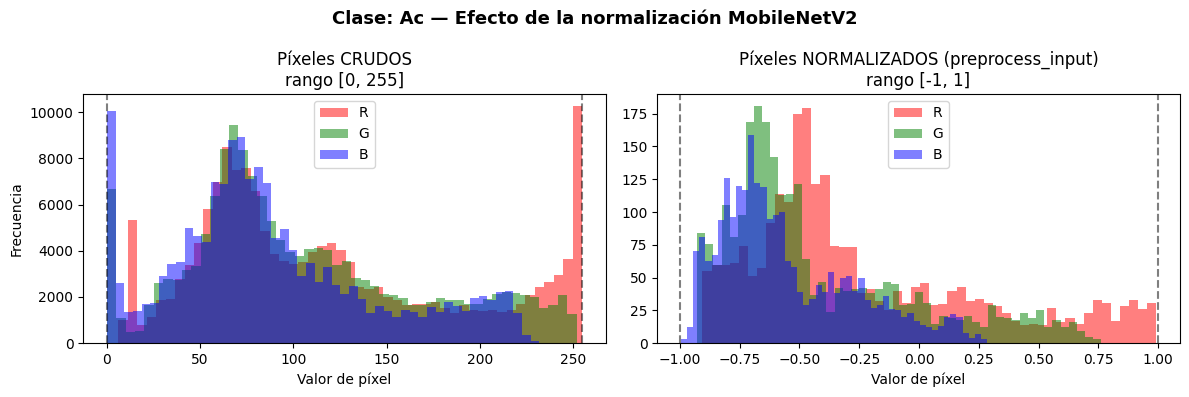

✓ Histograma guardado en /content/ccsn_histograma_normalizacion.png


In [ ]:
# Comparación visual del antes y después de la normalización

# Imagen cruda (PIL, uint8)
sample_path = sorted((DATA_ROOT / class_names[0]).glob('*.jpg'))[0]
img_cruda   = np.array(Image.open(sample_path).convert('RGB'), dtype=np.float32)

# Imagen normalizada (la misma, procesada por el pipeline)
img_norm = sample_imgs[0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma crudo
for i, (canal, color) in enumerate(zip(['R','G','B'], ['red','green','blue'])):
    axes[0].hist(img_cruda[:,:,i].ravel(), bins=50, alpha=0.5,
                 color=color, label=canal)
axes[0].set_title('Píxeles CRUDOS\nrango [0, 255]', fontsize=12)
axes[0].set_xlabel('Valor de píxel')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].axvline(0,   color='black', linestyle='--', alpha=0.5)
axes[0].axvline(255, color='black', linestyle='--', alpha=0.5)

# Histograma normalizado
for i, (canal, color) in enumerate(zip(['R','G','B'], ['red','green','blue'])):
    axes[1].hist(img_norm[:,:,i].ravel(), bins=50, alpha=0.5,
                 color=color, label=canal)
axes[1].set_title('Píxeles NORMALIZADOS (preprocess_input)\nrango [-1, 1]', fontsize=12)
axes[1].set_xlabel('Valor de píxel')
axes[1].legend()
axes[1].axvline(-1, color='black', linestyle='--', alpha=0.5, label='-1')
axes[1].axvline( 1, color='black', linestyle='--', alpha=0.5, label='+1')

plt.suptitle(f'Clase: {class_names[0]} — Efecto de la normalización MobileNetV2',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/ccsn_histograma_normalizacion.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ Histograma guardado en /content/ccsn_histograma_normalizacion.png')

## BLOQUE 5 C: Grilla visual — Imágenes "crudas" vs "normalizadas"

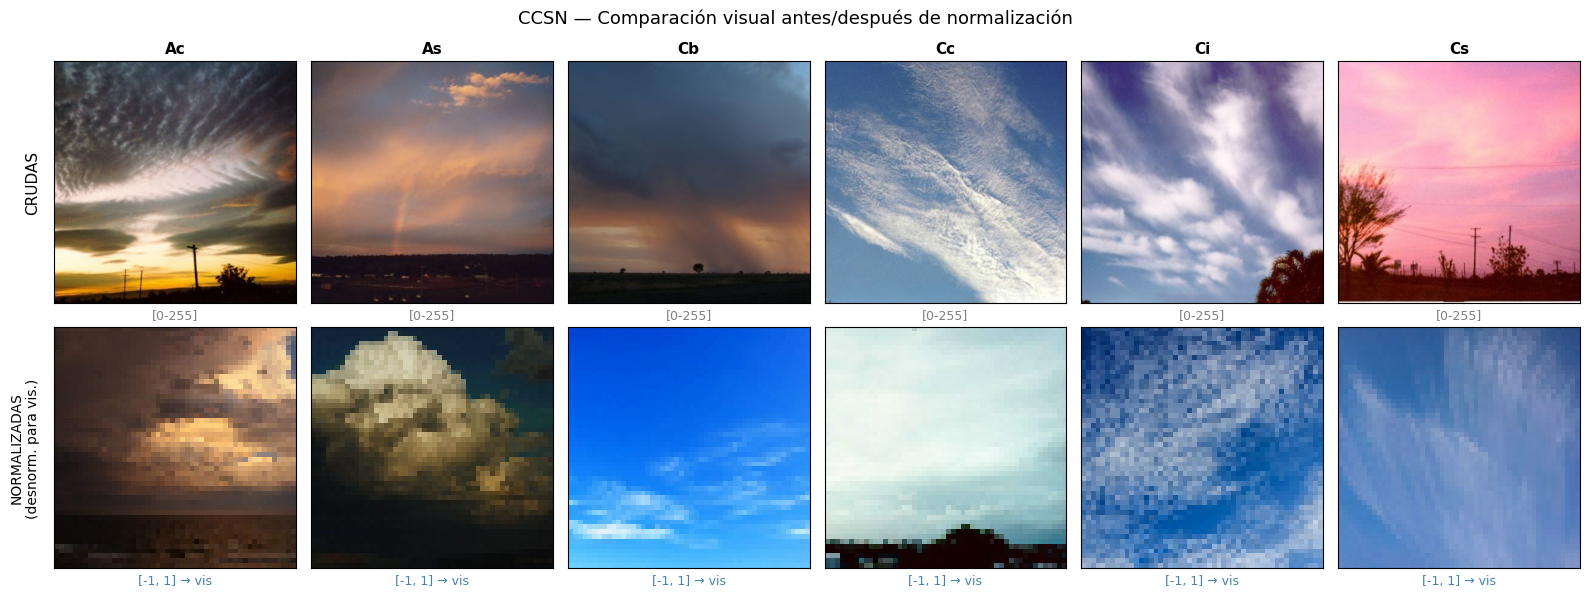

✓ Comparación guardada en /content/ccsn_comparacion_normalizacion.png


In [ ]:
# La imagen normalizada se "desnormaliza" solo para visualizar
# (no afecta el dataset, es solo para la figura)

def desnormalizar(img_norm):
    """Revierte preprocess_input para visualización. No usar en el pipeline."""
    return np.clip((img_norm + 1.0) / 2.0, 0, 1)

n_show = 6
fig, axes = plt.subplots(2, n_show, figsize=(16, 6))

for i in range(n_show):
    cls = class_names[i]

    # Fila superior: imágenes crudas
    img_file = sorted((DATA_ROOT / cls).glob('*.jpg'))[0]
    axes[0, i].imshow(Image.open(img_file).convert('RGB'))
    axes[0, i].set_title(cls, fontsize=11, fontweight='bold')
    axes[0, i].set_xlabel(f'[0-255]', fontsize=9, color='gray')
    axes[0, i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Fila inferior: imágenes normalizadas (desnormalizadas para ver)
    img_n = sample_imgs[i].numpy()
    axes[1, i].imshow(desnormalizar(img_n))
    axes[1, i].set_xlabel(f'[-1, 1] → vis', fontsize=9, color='steelblue')
    axes[1, i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

axes[0, 0].set_ylabel('CRUDAS', fontsize=11, rotation=90, labelpad=10)
axes[1, 0].set_ylabel('NORMALIZADAS\n(desnorm. para vis.)', fontsize=10, rotation=90, labelpad=10)

plt.suptitle('CCSN — Comparación visual antes/después de normalización', fontsize=13)
plt.tight_layout()
plt.savefig('/content/ccsn_comparacion_normalizacion.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ Comparación guardada en /content/ccsn_comparacion_normalizacion.png')

## **RESUMEN ESTATÍSTICO DEL DATASET: "Clase", "Imágenes" y "Distribución**"

In [ ]:
print('📊 RESUMEN ESTATÍSTICO DEL DATASET:')
print(f"{'Clase':<15} | {'Imágenes':<10} | {'Distribución'}")
print('-' * 45)

# Calculamos el total de imágenes basándonos en la inspección previa
total_general = sum(counts.values())

for nombre_clase in CLASS_NAMES:
    cantidad = counts.get(nombre_clase, 0)
    porcentaje = (cantidad / total_general) * 100
    # Dibujamos una pequeña barra visual para el informe
    barra = '█' * int(porcentaje // 2)
    print(f"{nombre_clase:<15} | {cantidad:<10} | {porcentaje:>5.1f}% {barra}")

print('-' * 45)
print(f"{'TOTAL':<15} | {total_general:<10} | 100.0%")

# Verificación de integridad del flujo (Tensor Check)
# Tomamos 1 batch real para asegurar que los datos están "vivos" y normalizados
for img_batch, label_batch in ds_train_norm.take(1):
    print(f"\n✅ Verificación de flujo: Batch detectado con forma {img_batch.shape}")
    print(f"✅ Rango de normalización: Min {np.min(img_batch):.2f} / Max {np.max(img_batch):.2f}")
    if np.min(img_batch) < 0:
        print("💡 Estado: Normalización MobileNetV2 [-1, 1] detectada correctamente.")

📊 RESUMEN ESTATÍSTICO DEL DATASET:
Clase           | Imágenes   | Distribución
---------------------------------------------
Ac              | 221        |   8.7% ████
As              | 188        |   7.4% ███
Cb              | 242        |   9.5% ████
Cc              | 268        |  10.5% █████
Ci              | 139        |   5.5% ██
Cs              | 287        |  11.3% █████
Ct              | 200        |   7.9% ███
Cu              | 182        |   7.2% ███
Ns              | 274        |  10.8% █████
Sc              | 340        |  13.4% ██████
St              | 202        |   7.9% ███
---------------------------------------------
TOTAL           | 2543       | 100.0%

✅ Verificación de flujo: Batch detectado con forma (50, 50, 3)
✅ Rango de normalización: Min -0.95 / Max 1.00
💡 Estado: Normalización MobileNetV2 [-1, 1] detectada correctamente.


---
## **💾 BLOQUE 6 — Guardado del dataset normalizado**
Guardamos el dataset como `tf.data.Dataset` serializado para reutilizarlo  
en el notebook de entrenamiento sin tener que recargar y renormalizar.

## BLOQUE 6 A: Guardar como tf.data.Dataset en Disco

In [ ]:
SAVE_DIR = Path('/content/ccsn_normalizado')

# Serializar — necesario hacer batch antes de save()
ds_train_batched = (
    ds_train_norm
    .shuffle(buffer_size=500, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
ds_val_batched = (
    ds_val_norm
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print('💾 Guardando dataset normalizado...')
tf.data.Dataset.save(ds_train_batched, str(SAVE_DIR / 'train'))
tf.data.Dataset.save(ds_val_batched,   str(SAVE_DIR / 'val'))

# Guardar también los nombres de clases
with open(SAVE_DIR / 'class_names.json', 'w') as f:
    json.dump(class_names, f)

print(f'✓ Dataset guardado en {SAVE_DIR}/')
print(f'   train/  → {n_train} imágenes normalizadas')
print(f'   val/    → {n_val} imágenes normalizadas')
print(f'   class_names.json → {class_names}')

💾 Guardando dataset normalizado...
✓ Dataset guardado en /content/ccsn_normalizado/
   train/  → 2035 imágenes normalizadas
   val/    → 508 imágenes normalizadas
   class_names.json → ['Ac', 'As', 'Cb', 'Cc', 'Ci', 'Cs', 'Ct', 'Cu', 'Ns', 'Sc', 'St']


## BLOQUE 6 B: Verificar que el dataset guardado se puede recargar

In [ ]:
# Definir el element_spec para poder recargar
element_spec = (
    tf.TensorSpec(shape=(None, 50, 50, 3), dtype=tf.float32), # Changed from 224 to 50
    tf.TensorSpec(shape=(None,),             dtype=tf.int32)
)

ds_train_reload = tf.data.Dataset.load(str(SAVE_DIR / 'train'), element_spec=element_spec)
ds_val_reload   = tf.data.Dataset.load(str(SAVE_DIR / 'val'),   element_spec=element_spec)

# Verificar un batch
for imgs, lbls in ds_train_reload.take(1):
    assert imgs.shape[1:] == (50, 50, 3), 'ERROR: shape incorrecto'
    assert imgs.numpy().min() >= -1.05,     'ERROR: rango de píxeles incorrecto'
    assert imgs.numpy().max() <=  1.05,     'ERROR: rango de píxeles incorrecto'
    print(f'✓ Recarga exitosa')
    print(f'   Shape: {imgs.shape}')
    print(f'   Rango: [{imgs.numpy().min():.3f}, {imgs.numpy().max():.3f}]')
    print(f'   Labels en este batch: {sorted(set(lbls.numpy().tolist()))}')

print(f'\n✓ El dataset normalizado está listo para usar en el notebook de entrenamiento')
print(f'\nPara cargar en otro notebook:')
print(f'   ds_train = tf.data.Dataset.load("/content/ccsn_normalizado/train", element_spec=...)')
print(f'   ds_val   = tf.data.Dataset.load("/content/ccsn_normalizado/val",   element_spec=...)')

✓ Recarga exitosa
   Shape: (32, 50, 50, 3)
   Rango: [-1.000, 1.000]
   Labels en este batch: [0, 1, 3, 4, 5, 6, 7, 8, 9, 10]

✓ El dataset normalizado está listo para usar en el notebook de entrenamiento

Para cargar en otro notebook:
   ds_train = tf.data.Dataset.load("/content/ccsn_normalizado/train", element_spec=...)
   ds_val   = tf.data.Dataset.load("/content/ccsn_normalizado/val",   element_spec=...)


---
## 📋 Resumen del pipeline de normalización

```
JPEG en disco (uint8, 256×256)  
        │
        ▼ image_dataset_from_directory(image_size=(50,50))
float32, 50×50, rango [0, 255]  
        │
        ▼ tf.cast(image, tf.float32)
float32, rango [0.0, 255.0]  
        │
        ▼ preprocess_input()  →  (x / 127.5) - 1.0
float32, rango [-1.0, 1.0]  ← listo para MobileNetV2
        │
        ▼ .batch(32).prefetch(AUTOTUNE)
Dataset batched listo para .fit()
```

**Próximo paso:** cargar `ds_train` y `ds_val` desde `/content/ccsn_normalizado/`  
en el notebook de entrenamiento y pasarlos directamente a `model.fit()`.

# **⚙️ BLOQUE 7: PREPARACIÓN Y MODELADO DE REDES NEURONALES (C N N)**

## BLOQUE 7 A:  Normalización y Entrenamiento del Modelo

In [ ]:
#Normalizacion
x_train = tf.data.Dataset.load("/content/ccsn_normalizado/train", element_spec=element_spec)
x_test   = tf.data.Dataset.load("/content/ccsn_normalizado/val",   element_spec=element_spec)

print(f"Tipo de x_train: {type(x_train)}")
print(f"Tipo de x_test: {type(x_test)}")

Tipo de x_train: <class 'tensorflow.python.data.ops.load_op._LoadDataset'>
Tipo de x_test: <class 'tensorflow.python.data.ops.load_op._LoadDataset'>


In [ ]:
print(f'Número de elementos en x_train (imágenes): {n_train}')
print(f'Número de elementos en x_test (imágenes): {n_val}')

Número de elementos en x_train (imágenes): 2035
Número de elementos en x_test (imágenes): 508


## BLOQUE 7 B: Modelado: Armado y Definición de Capas de la Red Neuronal

In [ ]:
modelo = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(50,50,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(len(CLASS_NAMES_TF), activation="softmax") # Cambiado de 10 a len(CLASS_NAMES_TF) (11 clases)
])

modelo.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 9, 9, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 5184)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       331,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,875 (1.48 MB)

 Trainable params: 388,875 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

## BLOQUE 7 C: Compilación de Modelo

In [ ]:
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## BLOQUE 7 D: Historial, Entrenamiento, Époch y Validación

In [ ]:
historial = modelo.fit(
    x_train, # x_train ya es un dataset que contiene (imágenes, etiquetas)
    epochs=14,
    validation_data=x_test # x_test ya es un dataset que contiene (imágenes, etiquetas)
)

Epoch 1/14
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9052 - loss: 0.2873 - val_accuracy: 0.7717 - val_loss: 1.0987
Epoch 2/14
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9189 - loss: 0.2552 - val_accuracy: 0.7500 - val_loss: 1.3156
Epoch 3/14
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9297 - loss: 0.2465 - val_accuracy: 0.7303 - val_loss: 1.4888
Epoch 4/14
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9342 - loss: 0.2203 - val_accuracy: 0.7303 - val_loss: 1.5257
Epoch 5/14
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9292 - loss: 0.2246 - val_accuracy: 0.7854 - val_loss: 1.1947
Epoch 6/14
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9302 - loss: 0.2116 - val_accuracy: 0.7677 - val_loss: 1.3167
Epoch 7/14
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9351 - loss: 0.2011 - val_accuracy: 0.8031 - val_loss: 1.1545
Epoch 8/14
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9376 - loss: 0.1751 - val_accuracy: 0.7874 - val_lo

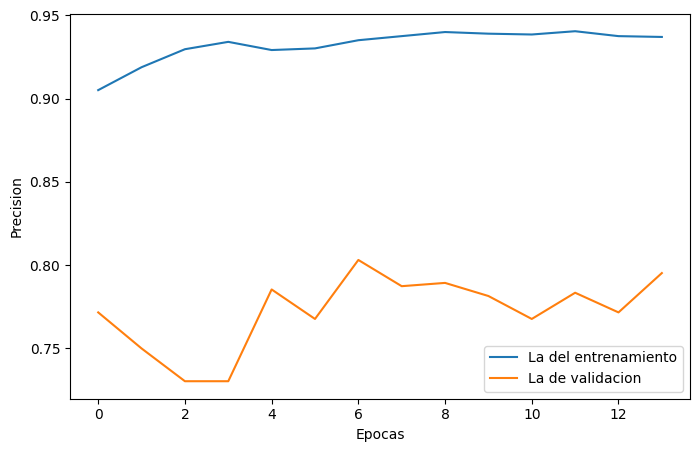

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(historial.history["accuracy"], label="La del entrenamiento")
plt.plot(historial.history["val_accuracy"], label="La de validacion")
plt.xlabel("Epocas")
plt.ylabel("Precision")
plt.legend()
plt.show()

# **BLOQUE 8: OBTENCIÓN DE IMÁGENES Y ETIQUETAS DEL DATASET - PREDICCIÓN DEL MODELO**

## BLOQUE 8 A: Selección de imágenes y etiquetas, para predicción del Modelo

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7953 - loss: 1.0852 
Perdida en testeo: 1.0851572751998901
Precision en testeo: 0.7952755689620972


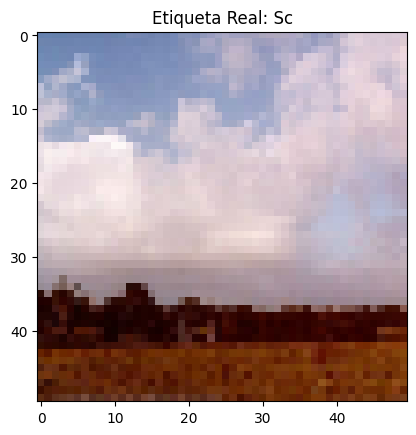

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Etiqueta real: Sc
Etiqueta predicha: Sc
Probabilidades de clase:  [[1.8161822e-05 4.7207025e-09 2.4296814e-06 1.0667339e-05 7.8859754e-09
  5.7711327e-03 3.5345282e-10 3.4592354e-05 8.0754886e-05 9.7387546e-01
  2.0206762e-02]]


In [ ]:
loss, accuracy = modelo.evaluate(x_test)
print(f"Perdida en testeo: {loss}")
print(f"Precision en testeo: {accuracy}")

# Obtener un batch de imágenes y etiquetas del dataset de test
# .take(1) obtiene un único batch
# .as_numpy_iterator().next() convierte el batch de tensores a NumPy arrays
images_batch, labels_batch = next(x_test.take(1).as_numpy_iterator())

# Seleccionar una imagen y su etiqueta del batch (por ejemplo, la primera)
imagen = images_batch[31]
etiqueta_real_idx = labels_batch[31]

# Desnormalizar la imagen para visualización (si está en el rango [-1, 1])
# Asumiendo que `desnormalizar` function from earlier is available, or do it manually
# MobileNetV2 preprocess_input maps [0, 255] to [-1, 1], so reverse is (img + 1) * 127.5
# Then clip to [0, 255] and cast to uint8 for imshow
imagen_display = np.clip((imagen + 1.0) / 2.0, 0, 1) # Normaliza a [0, 1] for display

plt.imshow(imagen_display)
plt.title(f"Etiqueta Real: {CLASS_NAMES_TF[etiqueta_real_idx]}") # Usamos CLASS_NAMES_TF
plt.show()

# Para la predicción, el modelo espera un batch, por lo que expandimos las dimensiones de la imagen
# Convertir la imagen a un array de NumPy y agregar una dimensión para el batch
imagen_para_predict = np.expand_dims(imagen, axis=0)

prediccion = modelo.predict(imagen_para_predict)
etiqueta_predicha = np.argmax(prediccion)

print(f"Etiqueta real: {CLASS_NAMES_TF[etiqueta_real_idx]}")
print(f"Etiqueta predicha: {CLASS_NAMES_TF[etiqueta_predicha]}")
print("Probabilidades de clase: ", prediccion)


# **BLOQUE 9: PRUEBA DEL MODELO PREDICTIVO, CON IMÁGENES EXTERNAS**

# Se probó el modelo con imágenes de distintos tipos de nubes externas, distinas de las imágenes del Dataset.

## El modelo clásifica correctamente las imágenes cargadas, aunque depende mucho de la clase de nube que busque clasificar, y su exactitud depende de como ha sido clasificada previamente la imágen, dado que la diferencia entre nubes, es an algunos casos muy pequeña.

Saving WhatsApp Image 2026-05-11 at 22.14.26.jpeg to WhatsApp Image 2026-05-11 at 22.14.26.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


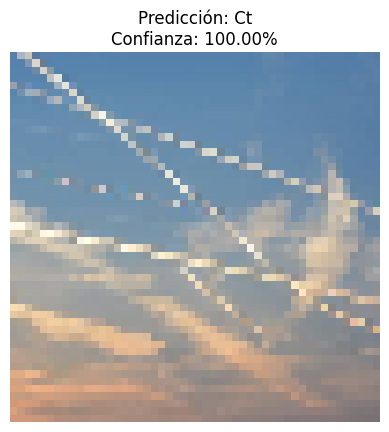

El modelo dice que esta nube es Ct con un 100.00% de certeza.


In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Subir el archivo
uploaded = files.upload()

for fn in uploaded.keys():
  # 2. Cargar y mostrar la imagen
  path = fn
  # IMPORTANTE: Usar el mismo tamaño que el entrenamiento (50, 50)
  img = image.load_img(path, target_size=(50, 50))
  img_array = image.img_to_array(img)

  # 3. Normalizar (Igual que hicimos en el pipeline)
  # Como usamos MobileNetV2, la normalización es (x / 127.5) - 1
  img_batch = np.expand_dims(img_array, axis=0)
  img_preprocessed = (img_batch / 127.5) - 1.0

  # 4. Realizar la predicción
  prediction = modelo.predict(img_preprocessed)
  score = tf.nn.softmax(prediction[0]) # Convertir a probabilidades
  clase_idx = np.argmax(prediction)
  confianza = 100 * np.max(prediction) # MobileNetV2 con Softmax da la prob. directa

  # 5. Mostrar resultado
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"Predicción: {class_names[clase_idx]}\nConfianza: {confianza:.2f}%")
  plt.show()

  print(f"El modelo dice que esta nube es {class_names[clase_idx]} con un {confianza:.2f}% de certeza.")

# **BLOQUE 10: PRUEBA DEL MODELO CON DATOS DEL MISMO DATA SET, UTILIZANDO RANDOM**.

## ESTE BLOQUE DE PRUEBA UTILIZA LA FUNCIÓN RANDOM, PARA SELECCIONAR UNA IMÁGEN AL AZAR DEL DATASET Y PROBAR SU PODER PREDICTIVO.

### CON ESTA PRUEBA EL MODELO TAMBIÉN CLASIFICA CORRECTAMENTE LA IMÁGENES QUE CAPTURA DEL DATA SET, AUNQUE ES UN MODELO QUE PUEDE MEJORAR AÚN MÁS SU CAPACIDAD DE PREDICCIÓN.

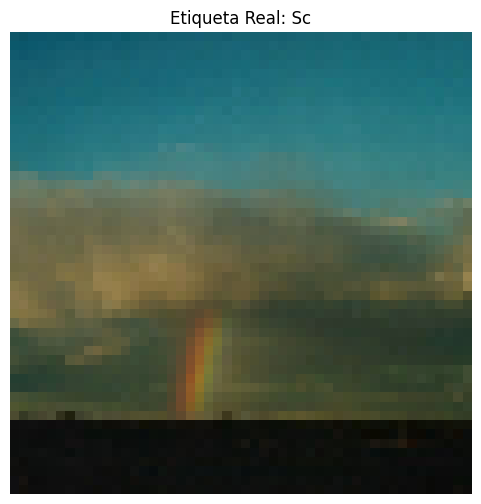

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Etiqueta real: Sc
Etiqueta predicha: St
Probabilidades de clase:  [[2.5027545e-04 3.1108067e-03 9.2236141e-06 9.1291813e-06 1.9559511e-07
  3.6187242e-03 9.7470350e-13 7.9583697e-02 1.6541779e-04 4.0702793e-01
  5.0622457e-01]]


In [ ]:
import random
import numpy as np

# Obtener un batch aleatorio del dataset de test
# Convertir el dataset a una lista de batches para poder seleccionar uno aleatoriamente
all_test_batches = list(x_test.as_numpy_iterator())

# Seleccionar un batch aleatorio
random_batch_index = random.randint(0, len(all_test_batches) - 1)
images_batch, labels_batch = all_test_batches[random_batch_index]

# Seleccionar una imagen aleatoria dentro de ese batch
random_image_index = random.randint(0, images_batch.shape[0] - 1)
imagen = images_batch[random_image_index]
etiqueta_real_idx = labels_batch[random_image_index]

# Desnormalizar la imagen para visualización
imagen_display = np.clip((imagen + 1.0) / 2.0, 0, 1) # Normaliza a [0, 1] for display

plt.figure(figsize=(6, 6))
plt.imshow(imagen_display)
plt.title(f"Etiqueta Real: {CLASS_NAMES_TF[etiqueta_real_idx]}")
plt.axis('off')
plt.show()

# Preparar la imagen para la predicción (agregar dimensión de batch)
imagen_para_predict = np.expand_dims(imagen, axis=0)

# Realizar la predicción
prediccion = modelo.predict(imagen_para_predict)
etiqueta_predicha = np.argmax(prediccion)

print(f"Etiqueta real: {CLASS_NAMES_TF[etiqueta_real_idx]}")
print(f"Etiqueta predicha: {CLASS_NAMES_TF[etiqueta_predicha]}")
print("Probabilidades de clase: ", prediccion)